# RAG — Stage 1: Ingestion

**Goal:** turn the raw SRS document (here: real **JDECo** PDF) into plain text, then **chunk** it for downstream embedding.

**In this mini-lab:**
- **Load** PDF/TXT via `load_document` (PyMuPDF for PDF).
- **Chunk** with `chunk_text` (LangChain `RecursiveCharacterTextSplitter`; sizes from `get_settings()`).

**Next notebook:** Stage 2 embeds each chunk and builds the FAISS index.


In [1]:
%pip install -q langchain-text-splitters langchain-core pymupdf python-dotenv


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
from pathlib import Path

# Run this notebook from the notebooks/ folder (parent = rag_lab).
RAG_LAB = Path("..").resolve()
SRC = RAG_LAB / "src"
sys.path.insert(0, str(SRC))

from qbrain_rag.application.chunking import chunk_text
from qbrain_rag.config.notebook_defaults import resolve_default_srs_path
from qbrain_rag.config.settings import get_settings
from qbrain_rag.infrastructure.document_loaders import load_document

srs_path = resolve_default_srs_path(RAG_LAB)
print("SRS path:", srs_path)

text = load_document(str(srs_path))
chunks = chunk_text(text)

s = get_settings()
print("chunk_size:", s.chunk_size, "overlap:", s.chunk_overlap)
print("characters:", len(text))
print("chunks:", len(chunks))
print("--- preview (first chunk, 800 chars) ---")
print(chunks[0][:800])


SRS path: D:\Qbrainpython\QBrain\rag_lab\data\srs\JDECo_SRS.docx[1].pdf
chunk_size: 2000 overlap: 300
characters: 45175
chunks: 30
--- preview (first chunk, 800 chars) ---
Software Requirements 
Specification 
for 
JDECo Services Management 
system 
Version 1.0 approved 
 
Prepared by :Hana Albidaq, Shahd Muharb, Hadeel Sawalha, Salam Rabi 
 
Birzeit University 
 
February 26,2023 
 
Copyright © 2013 by Karl Wiegers and Seilevel. Permission is granted to use and modify this document. 
1 

Software Requirements Specification for JDECo Services Management system​
​
 
Table of Contents 
1. Introduction​
5 
1.1 Purpose​
5 
1.2 Document Conventions​
5 
1.3 Project Scope​
5 
1.4 References​
6 
2. Overall Description​
6 
2.1 Product Perspective​
6 
2.2 User Classes and Characteristics​
7 
2.2.1 JDECo-SMS Class Diagram​
7 
2.2.2 JDECo Use Cases​
9 
2.2.3 JEDCo-Uses Case Diagram​
9 
2.3 Operating Environment​
13 
2.4 Design and Implementation Constraints​
14 
2.5 Ass


## Qualitative Figure: Retrieval + Generation Example (Actual Run)

This section builds a figure you can screenshot for the paper, showing:
1. Question
2. Retrieved top-k chunks from FAISS (actual retrieval)
3. Generated answer from the model (actual generation)

It also saves a high-resolution PNG to `../results/figures/qualitative_jdeco_example.png`.

> Note: this cell requires a valid `OPENAI_API_KEY` to run generation.

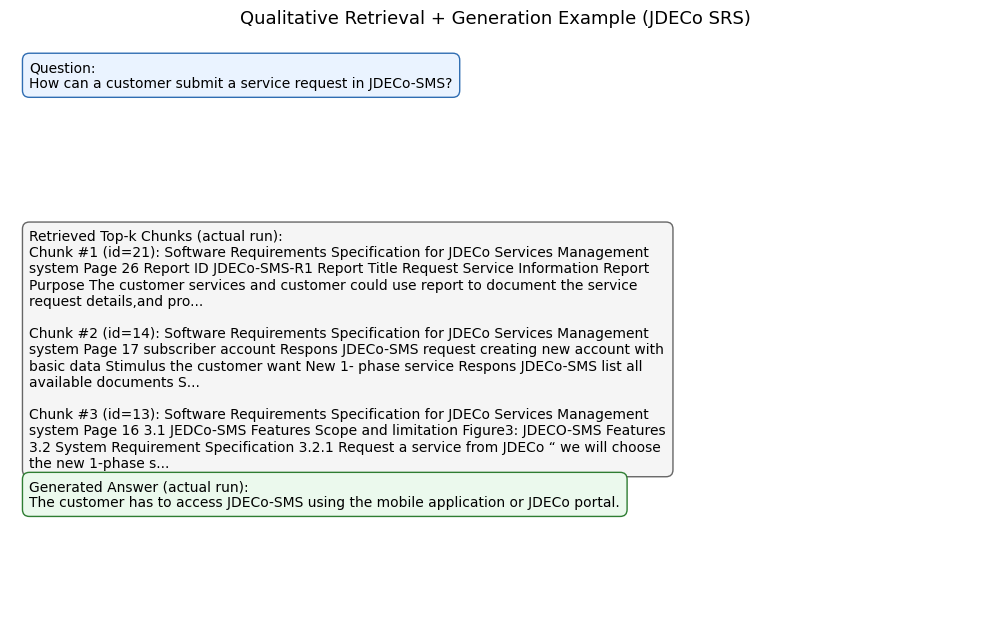

Saved figure to: D:\Qbrainpython\QBrain\rag_lab\results\figures\qualitative_jdeco_example.png

Retrieved chunk IDs: [21, 14, 13]
Generated answer:
 The customer has to access JDECo-SMS using the mobile application or JDECo portal.


In [3]:
import matplotlib.pyplot as plt
from textwrap import fill
from pathlib import Path

from qbrain_rag.infrastructure.vector_store import build_faiss_store, retrieve_top_k
from qbrain_rag.infrastructure.llm import answer_with_context

# Dynamic example: this question goes through real retrieval + generation.
question = "How can a customer submit a service request in JDECo-SMS?"
k = 3

metadata = [{"source_file": srs_path.name, "chunk_id": i + 1} for i in range(len(chunks))]
store = build_faiss_store(chunks, metadata)
docs = retrieve_top_k(store, question, k=k)

generated_answer = answer_with_context(question, docs, temperature=0.1, evaluation_mode=True)

chunks_topk = []
for rank, d in enumerate(docs, start=1):
    chunk_id = d.metadata.get("chunk_id", "?")
    snippet = " ".join(d.page_content.split())[:260]
    chunks_topk.append(f"Chunk #{rank} (id={chunk_id}): {snippet}...")

fig, ax = plt.subplots(figsize=(10, 6.4))
ax.axis("off")

q_text = "Question:\n" + fill(question, 88)
c_text = "Retrieved Top-k Chunks (actual run):\n" + "\n\n".join(fill(c, 88) for c in chunks_topk)
a_text = "Generated Answer (actual run):\n" + fill(generated_answer, 88)

ax.text(
    0.02,
    0.96,
    q_text,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#eaf3ff", edgecolor="#2f6db2"),
)
ax.text(
    0.02,
    0.67,
    c_text,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#f5f5f5", edgecolor="#666666"),
)
ax.text(
    0.02,
    0.24,
    a_text,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#ebf9ed", edgecolor="#2e7d32"),
)

ax.set_title("Qualitative Retrieval + Generation Example (JDECo SRS)", fontsize=13, pad=10)
plt.tight_layout()

out_path = Path("..") / "results" / "figures" / "qualitative_jdeco_example.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", out_path.resolve())
print("\nRetrieved chunk IDs:", [d.metadata.get("chunk_id") for d in docs])
print("Generated answer:\n", generated_answer)